In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

In [18]:
apps_df = pd.read_csv('Play Store Data.csv')

apps_df['Rating'] = pd.to_numeric(apps_df['Rating'], errors='coerce')

def parse_size(s):
    s = str(s)
    if 'M' in s: return float(s.replace('M', ''))
    elif 'k' in s: return float(s.replace('k', '')) / 1024
    return None
apps_df['Size_MB'] = apps_df['Size'].apply(parse_size)

apps_df['Installs_Clean'] = pd.to_numeric(
    apps_df['Installs'].astype(str).str.replace('[+,]', '', regex=True),
    errors='coerce'
)

apps_df['Reviews'] = pd.to_numeric(
    apps_df['Reviews'].astype(str).str.replace(',', ''),
    errors='coerce'
)

apps_df['Last_Updated_Month'] = pd.to_datetime(
    apps_df['Last Updated'], errors='coerce').dt.month_name()

In [7]:
print("Reviews dtype:", apps_df['Reviews'].dtype)
print(apps_df['Reviews'].head(5))

Reviews dtype: float64
0       159.0
1       967.0
2     87510.0
3    215644.0
4       967.0
Name: Reviews, dtype: float64


In [19]:
filtered = apps_df[
    (apps_df['Rating'] >= 4.0) &
    (apps_df['Size_MB'] >= 10) &
    (apps_df['Last_Updated_Month'] == 'January')
].copy()
print(f"Rows after filtering: {len(filtered)}")

Rows after filtering: 131


In [20]:
top10_cats = (
    filtered.groupby('Category')['Installs_Clean']
    .sum().nlargest(10).index.tolist()
)
top10_df = filtered[filtered['Category'].isin(top10_cats)]

agg = top10_df.groupby('Category').agg(
    Avg_Rating=('Rating', 'mean'),
    Total_Reviews=('Reviews', 'sum')
).reset_index()

agg['Rank'] = agg['Category'].map({c: i for i, c in enumerate(top10_cats)})
agg = agg.sort_values('Rank').reset_index(drop=True)
agg['Avg_Rating'] = agg['Avg_Rating'].round(2)
print(agg)

          Category  Avg_Rating  Total_Reviews  Rank
0           FAMILY        4.40      4544623.0     0
1           SPORTS        4.34      1982017.0     1
2             GAME        4.31      2397589.0     2
3    ENTERTAINMENT        4.25      1238948.0     3
4  PERSONALIZATION        4.47       155996.0     4
5      PHOTOGRAPHY        4.15       563720.0     5
6        LIFESTYLE        4.38        42809.0     6
7        EDUCATION        4.40        57645.0     7
8         SHOPPING        4.20        19950.0     8
9            TOOLS        4.20         8010.0     9


In [21]:
reviews_m = agg['Total_Reviews'] / 1e6

In [24]:
from datetime import datetime
from zoneinfo import ZoneInfo

ist_now = datetime.now(ZoneInfo("Asia/Kolkata"))
current_hour = ist_now.hour

if 15 <= current_hour < 17:
    fig, ax1 = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor('#0f1117')
    ax1.set_facecolor('#161b26')

    x = np.arange(len(agg))
    width = 0.38

    bars1 = ax1.bar(x - width/2, agg['Avg_Rating'], width,
                    color='#4f9cf9', alpha=0.85, label='Avg Rating', zorder=3)

    ax2 = ax1.twinx()
    reviews_m = agg['Total_Reviews'] / 1e6
    bars2 = ax2.bar(x + width/2, reviews_m, width,
                    color='#a78bfa', alpha=0.85, label='Total Reviews (M)', zorder=3)

    ax1.set_xticks(x)
    ax1.set_xticklabels(agg['Category'], rotation=30, ha='right', color='#8892a4', fontsize=10)
    ax1.set_ylabel('Average Rating', color='#4f9cf9', fontsize=11)
    ax2.set_ylabel('Total Reviews (Millions)', color='#a78bfa', fontsize=11)
    ax1.tick_params(colors='#8892a4')
    ax2.tick_params(colors='#8892a4')
    ax1.yaxis.set_tick_params(labelcolor='#4f9cf9')
    ax2.yaxis.set_tick_params(labelcolor='#a78bfa')
    ax1.set_ylim(3.8, 5.0)

    ax1.grid(axis='y', color='#252c3d', linestyle='--', alpha=0.3, zorder=0)
    ax1.set_axisbelow(True)

    for bar in bars1:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}',
                 ha='center', va='bottom',
                 color='#4f9cf9', fontsize=8, fontweight='bold')

    for bar in bars2:
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{bar.get_height():.1f}M',
                 ha='center', va='bottom',
                 color='#a78bfa', fontsize=8, fontweight='bold')

    plt.title('Top 10 App Categories — Avg Rating vs Total Reviews\n'
              'Filters: Rating ≥ 4.0 | Size ≥ 10 MB | Last Updated: January',
              color='#e8eaf0', fontsize=13, fontweight='bold', pad=20)

    patch1 = mpatches.Patch(color='#4f9cf9', label='Avg Rating')
    patch2 = mpatches.Patch(color='#a78bfa', label='Total Reviews (M)')
    ax1.legend(handles=[patch1, patch2], loc='upper left',
               facecolor='#1e2435', labelcolor='#8892a4',
               edgecolor='#252c3d', fontsize=10)

    for spine in ax1.spines.values():
        spine.set_edgecolor('#252c3d')
    for spine in ax2.spines.values():
        spine.set_edgecolor('#252c3d')

    plt.tight_layout()
    plt.show()

else:
    print(f"Chart only available between 3:00 PM 5:00 PM IST.")
    print(f"Current IST time: {ist_now.strftime('%I:%M %p')}")

Chart only available between 3:00 PM 5:00 PM IST.
Current IST time: 08:26 PM


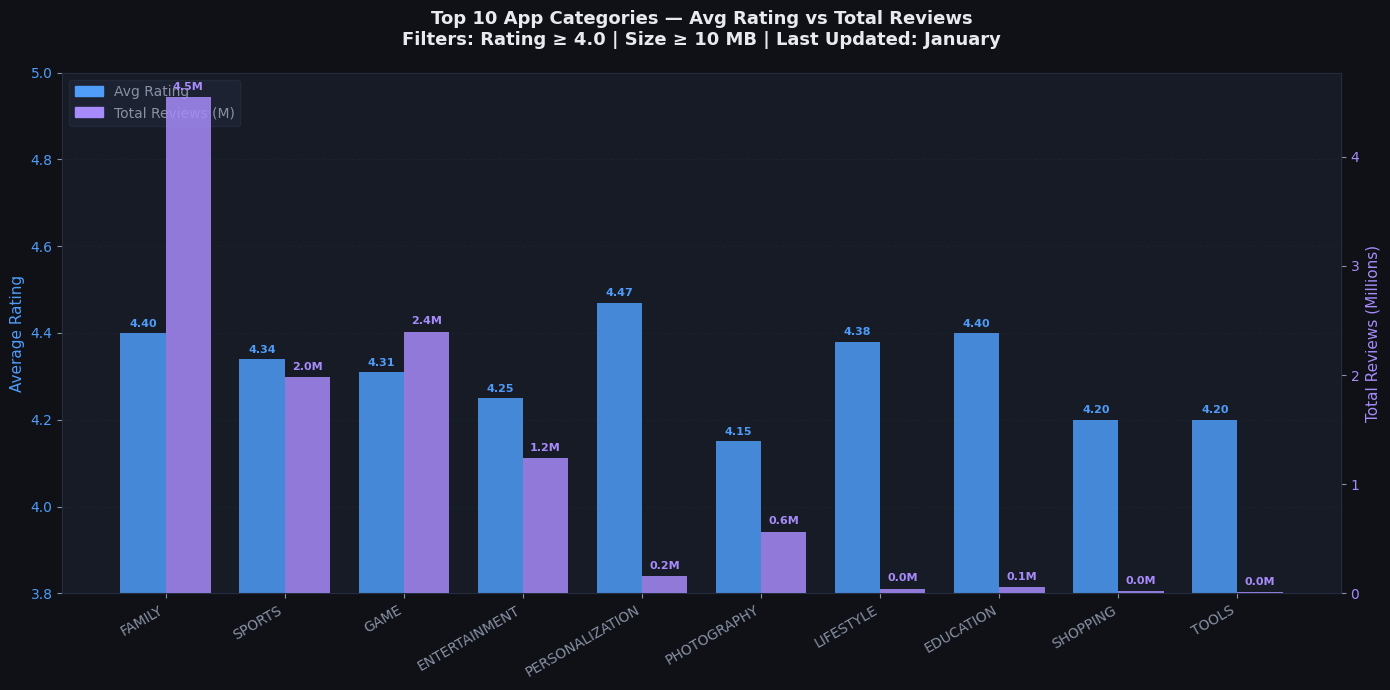

In [25]:
fig, ax1 = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0f1117')
ax1.set_facecolor('#161b26')

x = np.arange(len(agg))
width = 0.38

# Bar 1 — Avg Rating (left axis)
bars1 = ax1.bar(x - width/2, agg['Avg_Rating'], width,
                color='#4f9cf9', alpha=0.85,
                label='Avg Rating', zorder=3)

# Bar 2 — Reviews in Millions (right axis)
ax2 = ax1.twinx()
reviews_m = agg['Total_Reviews'] / 1e6
bars2 = ax2.bar(x + width/2, reviews_m, width,
                color='#a78bfa', alpha=0.85,
                label='Total Reviews (M)', zorder=3)

# Labels & formatting
ax1.set_xticks(x)
ax1.set_xticklabels(agg['Category'], rotation=30,
                     ha='right', color='#8892a4', fontsize=10)
ax1.set_ylabel('Average Rating', color='#4f9cf9', fontsize=11)
ax2.set_ylabel('Total Reviews (Millions)', color='#a78bfa', fontsize=11)
ax1.tick_params(colors='#8892a4')
ax2.tick_params(colors='#8892a4')
ax1.yaxis.set_tick_params(labelcolor='#4f9cf9')
ax2.yaxis.set_tick_params(labelcolor='#a78bfa')
ax1.set_ylim(3.8, 5.0)

# Grid
ax1.grid(axis='y', color='#252c3d',
         linestyle='--', alpha=0.3, zorder=0)
ax1.set_axisbelow(True)

# Value labels on bars
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{bar.get_height():.2f}',
             ha='center', va='bottom',
             color='#4f9cf9', fontsize=8, fontweight='bold')

for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{bar.get_height():.1f}M',
             ha='center', va='bottom',
             color='#a78bfa', fontsize=8, fontweight='bold')

# Title & legend
plt.title('Top 10 App Categories — Avg Rating vs Total Reviews\n'
          'Filters: Rating ≥ 4.0 | Size ≥ 10 MB | Last Updated: January',
          color='#e8eaf0', fontsize=13, fontweight='bold', pad=20)

patch1 = mpatches.Patch(color='#4f9cf9', label='Avg Rating')
patch2 = mpatches.Patch(color='#a78bfa', label='Total Reviews (M)')
ax1.legend(handles=[patch1, patch2], loc='upper left',
           facecolor='#1e2435', labelcolor='#8892a4',
           edgecolor='#252c3d', fontsize=10)

# Spine styling
for spine in ax1.spines.values():
    spine.set_edgecolor('#252c3d')
for spine in ax2.spines.values():
    spine.set_edgecolor('#252c3d')

plt.tight_layout()
plt.show()